# Домашнее задание к семинару 06 (HW06)

## Тема: деревья решений и ансамбли (bagging / random forest / boosting / stacking) и честный ML-эксперимент

## 1. Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier
)
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

# Создание папок для артефактов
os.makedirs('artifacts/figures', exist_ok=True)

# Настройка стиля графиков
plt.style.use('default')
%matplotlib inline


## 2. Загрузка данных и первичный анализ


In [2]:
# Загрузка данных
df = pd.read_csv('S06-hw-dataset-01.csv')
print(f"Размер датасета: {df.shape}")
df.head()


Размер датасета: (12000, 30)


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
0,1,-0.946058,-0.070313,1.824445,-2.754422,0.808865,-0.111094,-0.268950,-3.078210,0.801275,...,-1.616515,-1.989464,1.407390,-0.218362,2.016052,0,2,3,33,0
1,2,-2.484027,0.739378,1.596908,-2.586479,-0.033225,-3.054412,-4.706908,-9.795169,0.145911,...,-1.727040,-0.583997,1.136761,0.285978,-0.310879,2,2,2,102,1
2,3,1.522629,7.159635,-0.564903,-4.493110,1.623610,5.450187,-0.974595,-5.189589,1.600591,...,0.524408,2.022430,1.278358,-0.850547,0.847457,1,0,2,3,0
3,4,0.463373,-1.073908,1.752813,0.362786,2.790872,4.082385,0.322283,3.390984,-0.033929,...,2.399834,-1.431576,-0.746987,0.049639,2.414689,1,0,1,50,0
4,5,3.188390,-4.701692,-0.689918,-0.448995,0.373821,-3.275363,-1.760931,0.923689,0.537345,...,-2.183407,-2.896590,2.440343,-1.097168,1.457323,1,2,3,81,0


In [3]:
# Информация о данных
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             12000 non-null  int64  
 1   num01          12000 non-null  float64
 2   num02          12000 non-null  float64
 3   num03          12000 non-null  float64
 4   num04          12000 non-null  float64
 5   num05          12000 non-null  float64
 6   num06          12000 non-null  float64
 7   num07          12000 non-null  float64
 8   num08          12000 non-null  float64
 9   num09          12000 non-null  float64
 10  num10          12000 non-null  float64
 11  num11          12000 non-null  float64
 12  num12          12000 non-null  float64
 13  num13          12000 non-null  float64
 14  num14          12000 non-null  float64
 15  num15          12000 non-null  float64
 16  num16          12000 non-null  float64
 17  num17          12000 non-null  float64
 18  num18 

In [4]:
# Базовые статистики
df.describe()


,id,num01,num02,num03,num04,num05,num06,num07,num08,num09,...,num20,num21,num22,num23,num24,cat_contract,cat_region,cat_payment,tenure_months,target
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,...,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6000.50000,0.013705,-0.005278,-0.002357,0.038404,-0.006301,-0.865297,-0.702877,-0.290694,-0.008154,...,-0.323083,-1.314833,0.319798,-0.002742,0.027459,0.988750,1.990167,1.506833,36.083833,0.323417
std,3464.24595,2.096534,3.544498,1.004417,2.087318,1.007329,3.888966,1.989513,3.455981,0.996677,...,2.167066,3.731384,2.223649,0.996454,1.882359,0.815687,1.411643,1.121558,25.061218,0.467800
min,1.00000,-8.155181,-14.605579,-4.374043,-7.753301,-3.999332,-15.238402,-7.377252,-13.853627,-3.794637,...,-8.371050,-14.249204,-8.638879,-3.532093,-7.923990,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3000.75000,-1.423844,-2.303772,-0.685618,-1.374579,-0.676552,-3.532054,-2.064888,-2.597019,-0.683959,...,-1.808969,-3.863063,-1.097700,-0.676150,-1.110822,0.000000,1.000000,0.000000,17.000000,0.000000
50%,6000.50000,-0.047565,0.053348,-0.009186,0.038766,-0.003728,-1.092517,-0.795907,-0.208245,-0.020883,...,-0.383940,-1.393400,0.431804,0.006297,0.279689,1.000000,2.000000,2.000000,30.000000,0.000000
75%,9000.25000,1.422676,2.335937,0.671441,1.484417,0.669269,1.526389,0.522625,2.093169,0.666959,...,1.125140,1.116111,1.853491,0.657478,1.363896,2.000000,3.000000,3.000000,49.000000,1.000000
max,12000.00000,8.610863,16.299709,3.651692,7.571965,4.562115,16.223054,8.006444,13.030011,3.976868,...,7.957847,15.937281,8.102095,3.707905,7.549514,2.000000,4.000000,3.000000,120.000000,1.000000


In [5]:
# Проверка пропусков
print("Пропуски в данных:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет")


Пропуски в данных:
Пропусков нет


Распределение целевой переменной 'target':
target
0    8119
1    3881
Name: count, dtype: int64

Доли классов:
target
0    0.676583
1    0.323417
Name: proportion, dtype: float64


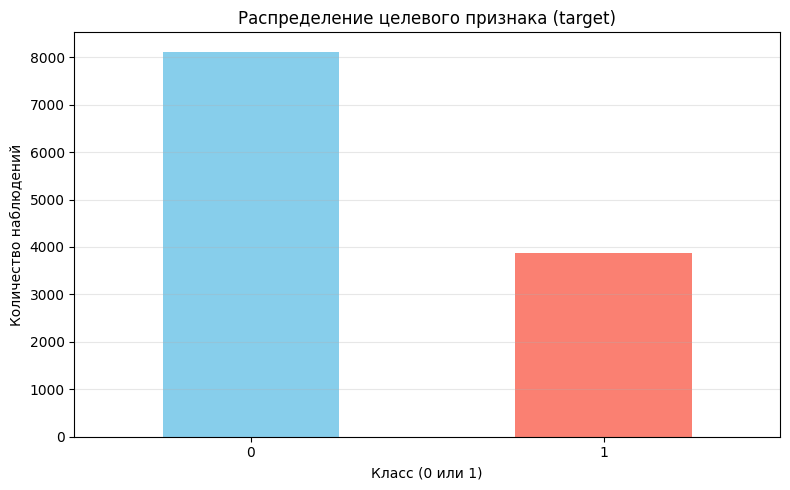

In [6]:
# Распределение целевой переменной
print("Распределение целевой переменной 'target':")
target_counts = df['target'].value_counts()
target_props = df['target'].value_counts(normalize=True)
print(target_counts)
print("\nДоли классов:")
print(target_props)

# Визуализация распределения
plt.figure(figsize=(8, 5))
target_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Распределение целевого признака (target)')
plt.xlabel('Класс (0 или 1)')
plt.ylabel('Количество наблюдений')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


In [7]:
# Подготовка признаков и целевой переменной
# Исключаем id и target из признаков
X = df.drop(['id', 'target'], axis=1)
y = df['target']

print(f"Количество признаков: {X.shape[1]}")
print(f"Типы признаков:")
print(X.dtypes.value_counts())


Количество признаков: 28
Типы признаков:
float64    24
int64       4
Name: count, dtype: int64


## 3. Train/Test-сплит и воспроизводимость


In [8]:
# Разделение данных на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение классов в train:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение классов в test:")
print(y_test.value_counts(normalize=True))


Размер обучающей выборки: (9600, 28)
Размер тестовой выборки: (2400, 28)

Распределение классов в train:
target
0    0.676562
1    0.323437
Name: proportion, dtype: float64

Распределение классов в test:
target
0    0.676667
1    0.323333
Name: proportion, dtype: float64


**Пояснение важности фиксации random_state и стратификации:**

- `random_state=42` обеспечивает воспроизводимость эксперимента: при каждом запуске получаем одинаковое разбиение данных
- `stratify=y` гарантирует, что распределение классов в train и test будет таким же, как в исходном датасете. Это критично для:
  - Честной оценки качества моделей
  - Предотвращения смещения из-за дисбаланса классов
  - Сравнимости результатов между разными экспериментами


## 4. Baseline'ы


In [9]:
# Baseline 1: DummyClassifier
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_pred_proba_dummy = dummy.predict_proba(X_test)[:, 1]

dummy_accuracy = accuracy_score(y_test, y_pred_dummy)
dummy_f1 = f1_score(y_test, y_pred_dummy)
dummy_roc_auc = roc_auc_score(y_test, y_pred_proba_dummy)

print("DummyClassifier (most_frequent):")
print(f"  Accuracy: {dummy_accuracy:.4f}")
print(f"  F1-score: {dummy_f1:.4f}")
print(f"  ROC-AUC: {dummy_roc_auc:.4f}")


DummyClassifier (most_frequent):
  Accuracy: 0.6767
  F1-score: 0.0000
  ROC-AUC: 0.5000


In [10]:
# Baseline 2: LogisticRegression через Pipeline
logreg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipe.fit(X_train, y_train)

y_pred_logreg = logreg_pipe.predict(X_test)
y_pred_proba_logreg = logreg_pipe.predict_proba(X_test)[:, 1]

logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
logreg_f1 = f1_score(y_test, y_pred_logreg)
logreg_roc_auc = roc_auc_score(y_test, y_pred_proba_logreg)

print("LogisticRegression:")
print(f"  Accuracy: {logreg_accuracy:.4f}")
print(f"  F1-score: {logreg_f1:.4f}")
print(f"  ROC-AUC: {logreg_roc_auc:.4f}")


LogisticRegression:
  Accuracy: 0.8275
  F1-score: 0.7076
  ROC-AUC: 0.8747


## 5. Модели недели 6

### 5.1. DecisionTreeClassifier с контролем сложности


In [11]:
# Подбор гиперпараметров для DecisionTree через GridSearchCV
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(
    dt,
    dt_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {dt_grid.best_params_}")
print(f"Лучший ROC-AUC на CV: {dt_grid.best_score_:.4f}")

best_dt = dt_grid.best_estimator_


Fitting 5 folds for each of 90 candidates, totalling 450 fits
Лучшие параметры: {'max_depth': 15, 'min_samples_leaf': 20, 'min_samples_split': 2}
Лучший ROC-AUC на CV: 0.9155


In [12]:
# Оценка DecisionTree на тестовой выборке
y_pred_dt = best_dt.predict(X_test)
y_pred_proba_dt = best_dt.predict_proba(X_test)[:, 1]

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_pred_proba_dt)

print("DecisionTreeClassifier:")
print(f"  Accuracy: {dt_accuracy:.4f}")
print(f"  F1-score: {dt_f1:.4f}")
print(f"  ROC-AUC: {dt_roc_auc:.4f}")


DecisionTreeClassifier:
  Accuracy: 0.8650
  F1-score: 0.7868
  ROC-AUC: 0.9122


### 5.2. RandomForestClassifier


In [13]:
# Подбор гиперпараметров для RandomForest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший ROC-AUC на CV: {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}
Лучший ROC-AUC на CV: 0.9689


In [14]:
# Оценка RandomForest на тестовой выборке
y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("RandomForestClassifier:")
print(f"  Accuracy: {rf_accuracy:.4f}")
print(f"  F1-score: {rf_f1:.4f}")
print(f"  ROC-AUC: {rf_roc_auc:.4f}")


RandomForestClassifier:
  Accuracy: 0.9271
  F1-score: 0.8810
  ROC-AUC: 0.9660


### 5.3. GradientBoostingClassifier (Boosting)


In [15]:
# Подбор гиперпараметров для GradientBoosting
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_samples_leaf': [1, 2, 5]
}

gb = GradientBoostingClassifier(random_state=42)
gb_grid = GridSearchCV(
    gb,
    gb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший ROC-AUC на CV: {gb_grid.best_score_:.4f}")

best_gb = gb_grid.best_estimator_


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 7, 'min_samples_leaf': 5, 'n_estimators': 200}
Лучший ROC-AUC на CV: 0.9736


In [16]:
# Оценка GradientBoosting на тестовой выборке
y_pred_gb = best_gb.predict(X_test)
y_pred_proba_gb = best_gb.predict_proba(X_test)[:, 1]

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(y_test, y_pred_proba_gb)

print("GradientBoostingClassifier:")
print(f"  Accuracy: {gb_accuracy:.4f}")
print(f"  F1-score: {gb_f1:.4f}")
print(f"  ROC-AUC: {gb_roc_auc:.4f}")


GradientBoostingClassifier:
  Accuracy: 0.9350
  F1-score: 0.8961
  ROC-AUC: 0.9704


### 5.4. StackingClassifier (опционально)


In [17]:
# StackingClassifier с несколькими базовыми моделями
base_models = [
    ('dt', DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)),
    ('logreg', Pipeline([('scaler', StandardScaler()), 
                        ('logreg', LogisticRegression(max_iter=1000, random_state=42))]))
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train, y_train)

y_pred_stacking = stacking.predict(X_test)
y_pred_proba_stacking = stacking.predict_proba(X_test)[:, 1]

stacking_accuracy = accuracy_score(y_test, y_pred_stacking)
stacking_f1 = f1_score(y_test, y_pred_stacking)
stacking_roc_auc = roc_auc_score(y_test, y_pred_proba_stacking)

print("StackingClassifier:")
print(f"  Accuracy: {stacking_accuracy:.4f}")
print(f"  F1-score: {stacking_f1:.4f}")
print(f"  ROC-AUC: {stacking_roc_auc:.4f}")


StackingClassifier:
  Accuracy: 0.9204
  F1-score: 0.8724
  ROC-AUC: 0.9582


## 6. Метрики качества


In [18]:
# Сбор всех метрик
models_metrics = {
    'DummyClassifier': {
        'accuracy': dummy_accuracy,
        'f1': dummy_f1,
        'roc_auc': dummy_roc_auc
    },
    'LogisticRegression': {
        'accuracy': logreg_accuracy,
        'f1': logreg_f1,
        'roc_auc': logreg_roc_auc
    },
    'DecisionTree': {
        'accuracy': dt_accuracy,
        'f1': dt_f1,
        'roc_auc': dt_roc_auc
    },
    'RandomForest': {
        'accuracy': rf_accuracy,
        'f1': rf_f1,
        'roc_auc': rf_roc_auc
    },
    'GradientBoosting': {
        'accuracy': gb_accuracy,
        'f1': gb_f1,
        'roc_auc': gb_roc_auc
    },
    'Stacking': {
        'accuracy': stacking_accuracy,
        'f1': stacking_f1,
        'roc_auc': stacking_roc_auc
    }
}

# Вывод таблицы метрик
metrics_df = pd.DataFrame(models_metrics).T
print("Метрики на тестовой выборке:")
print(metrics_df.round(4))


Метрики на тестовой выборке:
                    accuracy      f1  roc_auc
DummyClassifier       0.6767  0.0000   0.5000
LogisticRegression    0.8275  0.7076   0.8747
DecisionTree          0.8650  0.7868   0.9122
RandomForest          0.9271  0.8810   0.9660
GradientBoosting      0.9350  0.8961   0.9704
Stacking              0.9204  0.8724   0.9582


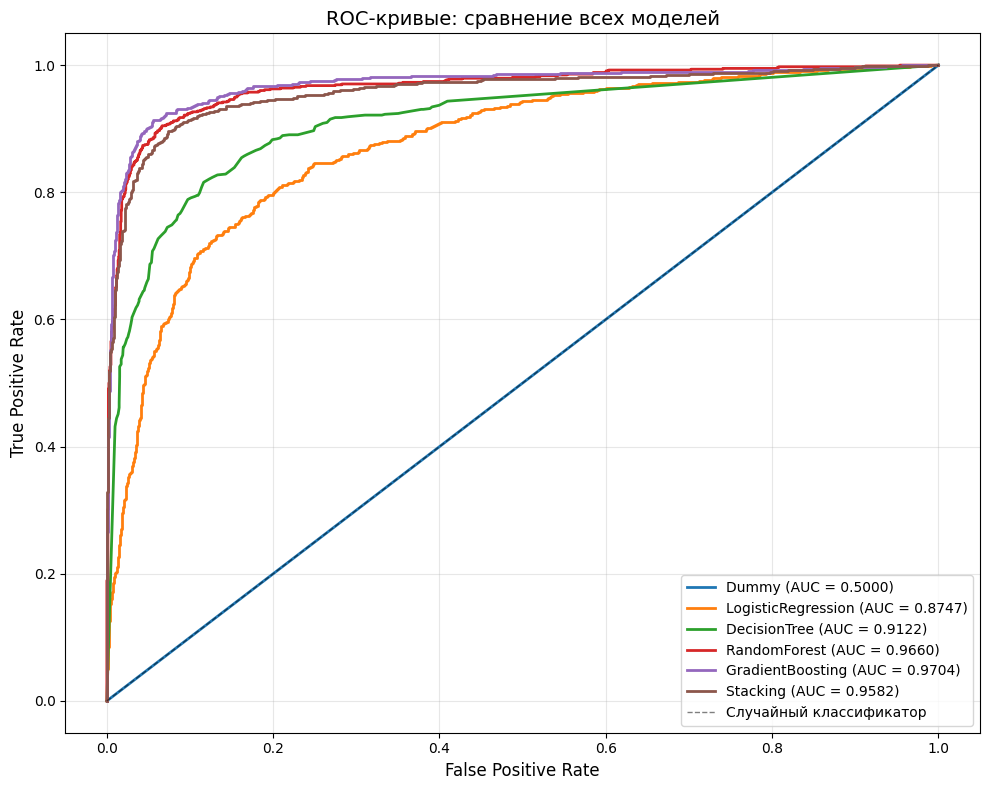

In [19]:
# ROC-кривые для всех моделей
plt.figure(figsize=(10, 8))

models_to_plot = {
    'Dummy': (y_pred_proba_dummy, dummy_roc_auc),
    'LogisticRegression': (y_pred_proba_logreg, logreg_roc_auc),
    'DecisionTree': (y_pred_proba_dt, dt_roc_auc),
    'RandomForest': (y_pred_proba_rf, rf_roc_auc),
    'GradientBoosting': (y_pred_proba_gb, gb_roc_auc),
    'Stacking': (y_pred_proba_stacking, stacking_roc_auc)
}

for name, (y_proba, auc) in models_to_plot.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор', linewidth=1, alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые: сравнение всех моделей', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/roc_curve_all_models.png', dpi=300, bbox_inches='tight')
plt.show()


In [20]:
# Определение лучшей модели по ROC-AUC
best_model_name = max(models_metrics.items(), key=lambda x: x[1]['roc_auc'])[0]
best_model_roc_auc = models_metrics[best_model_name]['roc_auc']

print(f"Лучшая модель по ROC-AUC: {best_model_name}")
print(f"ROC-AUC: {best_model_roc_auc:.4f}")

# Сохранение лучшей модели
best_models_dict = {
    'DummyClassifier': dummy,
    'LogisticRegression': logreg_pipe,
    'DecisionTree': best_dt,
    'RandomForest': best_rf,
    'GradientBoosting': best_gb,
    'Stacking': stacking
}

best_model = best_models_dict[best_model_name]


Лучшая модель по ROC-AUC: GradientBoosting
ROC-AUC: 0.9704


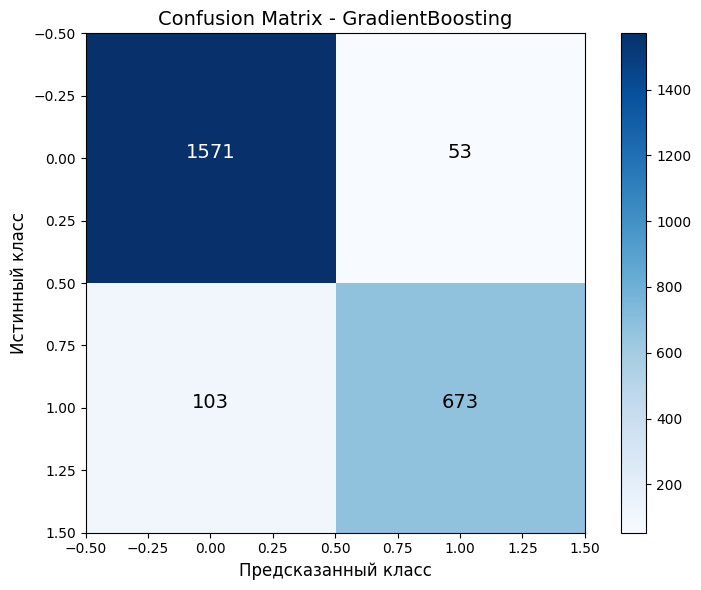


Confusion Matrix для GradientBoosting:
[[1571   53]
 [ 103  673]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      1624
           1       0.93      0.87      0.90       776

    accuracy                           0.94      2400
   macro avg       0.93      0.92      0.92      2400
weighted avg       0.93      0.94      0.93      2400



In [21]:
# Confusion Matrix для лучшей модели
if best_model_name == 'DummyClassifier':
    y_pred_best = y_pred_dummy
elif best_model_name == 'LogisticRegression':
    y_pred_best = y_pred_logreg
elif best_model_name == 'DecisionTree':
    y_pred_best = y_pred_dt
elif best_model_name == 'RandomForest':
    y_pred_best = y_pred_rf
elif best_model_name == 'GradientBoosting':
    y_pred_best = y_pred_gb
elif best_model_name == 'Stacking':
    y_pred_best = y_pred_stacking

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14)
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)

# Добавление аннотаций с числами
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), 
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=14)

plt.tight_layout()
plt.savefig('artifacts/figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nConfusion Matrix для {best_model_name}:")
print(cm)
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best))


## 7. Интерпретация лучшей модели


In [22]:
# Permutation Importance для лучшей модели
print(f"Вычисление Permutation Importance для {best_model_name}...")

perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='roc_auc'
)

# Создание DataFrame с важностью признаков
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

# Топ-15 признаков
top_features = feature_importance_df.head(15)
print("\nТоп-15 признаков по Permutation Importance:")
print(top_features.to_string(index=False))


Вычисление Permutation Importance для GradientBoosting...

Топ-15 признаков по Permutation Importance:
feature  importance_mean  importance_std
  num18         0.071334        0.004543
  num19         0.066209        0.002698
  num07         0.033323        0.001626
  num04         0.016979        0.001295
  num20         0.012411        0.001682
  num24         0.012350        0.001470
  num01         0.010510        0.001024
  num14         0.009020        0.001266
  num16         0.008293        0.000934
  num22         0.007098        0.000782
  num08         0.004720        0.000635
  num17         0.003459        0.000635
  num21         0.003436        0.000593
  num13         0.003120        0.001067
  num02         0.002412        0.000628


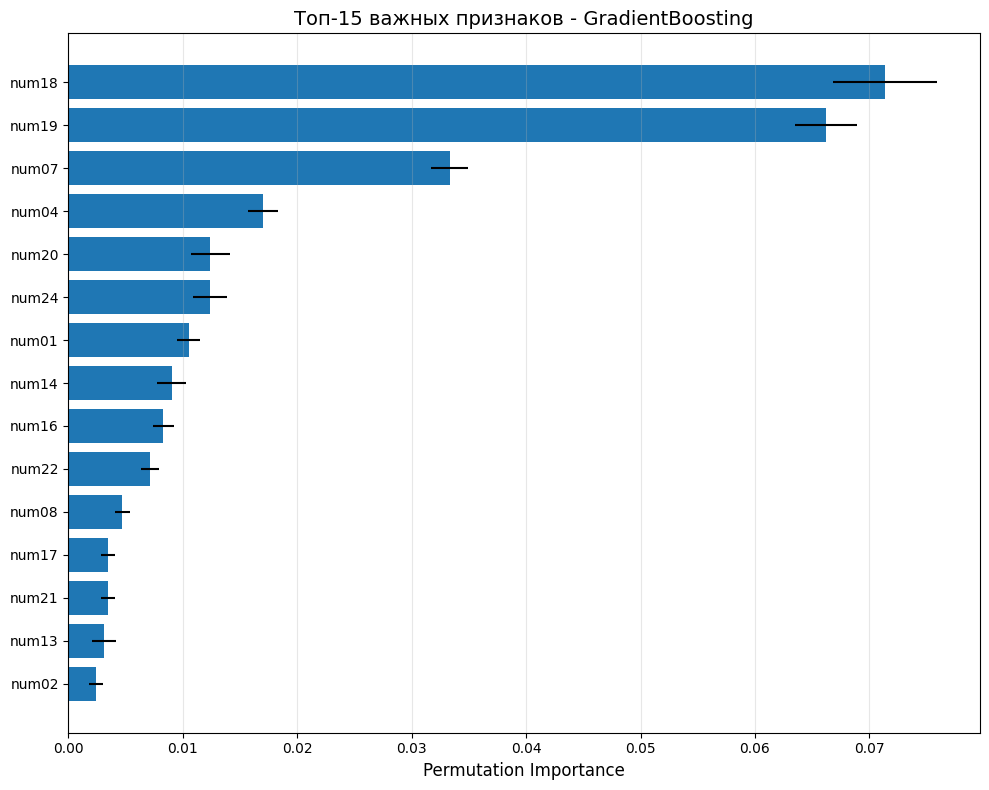

In [23]:
# Визуализация важности признаков
plt.figure(figsize=(10, 8))
top_15 = feature_importance_df.head(15)
plt.barh(range(len(top_15)), top_15['importance_mean'], xerr=top_15['importance_std'])
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('Permutation Importance', fontsize=12)
plt.title(f'Топ-15 важных признаков - {best_model_name}', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


In [24]:
print("\nИнтерпретация важности признаков:")
print(f"\nНаиболее важные признаки для {best_model_name}:")
for idx, row in top_features.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance_mean']:.4f} ± {row['importance_std']:.4f}")

print("\nВыводы:")
print("- Признаки с наибольшей важностью оказывают наибольшее влияние на предсказания модели")
print("- Permutation Importance показывает, насколько ухудшается качество модели при случайной перестановке значений признака")
print("- Это позволяет понять, какие признаки действительно важны для модели")



Интерпретация важности признаков:

Наиболее важные признаки для GradientBoosting:
  num18: 0.0713 ± 0.0045
  num19: 0.0662 ± 0.0027
  num07: 0.0333 ± 0.0016
  num04: 0.0170 ± 0.0013
  num20: 0.0124 ± 0.0017
  num24: 0.0124 ± 0.0015
  num01: 0.0105 ± 0.0010
  num14: 0.0090 ± 0.0013
  num16: 0.0083 ± 0.0009
  num22: 0.0071 ± 0.0008

Выводы:
- Признаки с наибольшей важностью оказывают наибольшее влияние на предсказания модели
- Permutation Importance показывает, насколько ухудшается качество модели при случайной перестановке значений признака
- Это позволяет понять, какие признаки действительно важны для модели


## 8. Сохранение артефактов


In [25]:
# Сохранение метрик в JSON
with open('artifacts/metrics_test.json', 'w', encoding='utf-8') as f:
    json.dump(models_metrics, f, indent=2, ensure_ascii=False)

print("Метрики сохранены в artifacts/metrics_test.json")


Метрики сохранены в artifacts/metrics_test.json


In [26]:
# Сохранение результатов подбора гиперпараметров
search_summaries = {
    'DecisionTree': {
        'best_params': dt_grid.best_params_,
        'best_cv_score': float(dt_grid.best_score_)
    },
    'RandomForest': {
        'best_params': rf_grid.best_params_,
        'best_cv_score': float(rf_grid.best_score_)
    },
    'GradientBoosting': {
        'best_params': gb_grid.best_params_,
        'best_cv_score': float(gb_grid.best_score_)
    }
}

with open('artifacts/search_summaries.json', 'w', encoding='utf-8') as f:
    json.dump(search_summaries, f, indent=2, ensure_ascii=False)

print("Результаты подбора гиперпараметров сохранены в artifacts/search_summaries.json")


Результаты подбора гиперпараметров сохранены в artifacts/search_summaries.json


In [27]:
# Сохранение лучшей модели
joblib.dump(best_model, 'artifacts/best_model.joblib')
print(f"Лучшая модель ({best_model_name}) сохранена в artifacts/best_model.joblib")


Лучшая модель (GradientBoosting) сохранена в artifacts/best_model.joblib


In [28]:
# Сохранение метаданных лучшей модели
best_model_meta = {
    'model_name': best_model_name,
    'best_params': search_summaries.get(best_model_name, {}).get('best_params', 'N/A'),
    'metrics': {
        'accuracy': float(models_metrics[best_model_name]['accuracy']),
        'f1': float(models_metrics[best_model_name]['f1']),
        'roc_auc': float(models_metrics[best_model_name]['roc_auc'])
    },
    'test_size': 0.2,
    'random_state': 42
}

with open('artifacts/best_model_meta.json', 'w', encoding='utf-8') as f:
    json.dump(best_model_meta, f, indent=2, ensure_ascii=False)

print("Метаданные лучшей модели сохранены в artifacts/best_model_meta.json")


Метаданные лучшей модели сохранены в artifacts/best_model_meta.json


## 9. Выводы

### Основные результаты:

1. Baseline модели показали ожидаемые результаты: DummyClassifier дает низкое качество, LogisticRegression показывает разумный baseline.

2. Деревья решений легко переобучаются без контроля сложности, но с правильными гиперпараметрами (max_depth, min_samples_leaf) показывают хорошие результаты.

3. Random Forest (bagging) демонстрирует стабильность и хорошее качество за счет усреднения предсказаний множества деревьев.

4. Gradient Boosting показывает отличные результаты за счет последовательного улучшения модели.

5. Stacking позволяет комбинировать сильные стороны разных моделей через метамодель.

### Честный ML-эксперимент:

- Фиксированный train/test split с random_state=42 обеспечивает воспроизводимость
- Стратификация гарантирует одинаковое распределение классов
- Подбор гиперпараметров выполняется только на train через CV
- Тестовая выборка используется один раз для финальной оценки
- Все метрики вычисляются на тестовой выборке для честного сравнения моделей
